In [1]:
import zipfile

zip_path = "/content/bank_data.zip"
extract_path = "/content/bank_data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", extract_path)


Extracted files: /content/bank_data/


In [2]:
import os

os.listdir("/content/bank_data/")


['bank.xlsx']

In [3]:
import pandas as pd

df = pd.read_excel("/content/bank_data/bank.xlsx")
df.head()


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


DATA CLEANING

In [4]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116201 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Account No           116201 non-null  object        
 1   DATE                 116201 non-null  datetime64[ns]
 2   TRANSACTION DETAILS  113702 non-null  object        
 3   CHQ.NO.              905 non-null     float64       
 4   VALUE DATE           116201 non-null  datetime64[ns]
 5   WITHDRAWAL AMT       53549 non-null   float64       
 6   DEPOSIT AMT          62652 non-null   float64       
 7   BALANCE AMT          116201 non-null  float64       
 8   .                    116201 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 8.0+ MB


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


Fix the '  in Account Numbers

In [5]:
df['Account No'] = df['Account No'].astype(str)

# Remove all quote-like characters
df['Account No'] = df['Account No'].str.replace("’", "", regex=False)
df['Account No'] = df['Account No'].str.replace("'", "", regex=False)
df['Account No'] = df['Account No'].str.replace("`", "", regex=False)
df['Account No'] = df['Account No'].str.strip()

df['Account No'].head()



,Account No
0,409000611074
1,409000611074
2,409000611074
3,409000611074
4,409000611074


Convert Dates to proper datetime

In [6]:
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['VALUE DATE'] = pd.to_datetime(df['VALUE DATE'], errors='coerce')

df[['DATE', 'VALUE DATE']].head()


,DATE,VALUE DATE
0,2017-06-29,2017-06-29
1,2017-07-05,2017-07-05
2,2017-07-18,2017-07-18
3,2017-08-01,2017-08-01
4,2017-08-16,2017-08-16


Fix missing cheque numbers

In [7]:
df['CHQ.NO.'] = df['CHQ.NO.'].fillna('')



Replace missing amounts with 0

In [8]:
df['WITHDRAWAL AMT'] = df['WITHDRAWAL AMT'].fillna(0)
df['DEPOSIT AMT'] = df['DEPOSIT AMT'].fillna(0)


Create a unified "Amount" column

In [9]:
df['Amount'] = df['DEPOSIT AMT'] - df['WITHDRAWAL AMT']
df[['WITHDRAWAL AMT', 'DEPOSIT AMT', 'Amount']].head()


,WITHDRAWAL AMT,DEPOSIT AMT,Amount
0,0.0,1000000.0,1000000.0
1,0.0,1000000.0,1000000.0
2,0.0,500000.0,500000.0
3,0.0,3000000.0,3000000.0
4,0.0,500000.0,500000.0


Check for duplicates

In [10]:
df = df.drop_duplicates()


In [11]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed|^\.$")]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 116162 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Account No           116162 non-null  object        
 1   DATE                 116162 non-null  datetime64[ns]
 2   TRANSACTION DETAILS  113663 non-null  object        
 3   CHQ.NO.              116162 non-null  object        
 4   VALUE DATE           116162 non-null  datetime64[ns]
 5   WITHDRAWAL AMT       116162 non-null  float64       
 6   DEPOSIT AMT          116162 non-null  float64       
 7   BALANCE AMT          116162 non-null  float64       
 8   Amount               116162 non-null  float64       
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 8.9+ MB


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1636401182.py:1: SyntaxWarning: invalid escape sequence '\.'
  df = df.loc[:, ~df.columns.str.contains("^Unnamed|^\.$")]


In [12]:
df.describe()
df.isna().sum()


,0
Account No,0
DATE,0
TRANSACTION DETAILS,2499
CHQ.NO.,0
VALUE DATE,0
WITHDRAWAL AMT,0
DEPOSIT AMT,0
BALANCE AMT,0
Amount,0


TRANSACTION DETAILS — 2499 NaN

This is normal because some transactions (like interest, charges, balance entries) don’t have narration.

We will fix those later using:

category inference

pattern matching

fallback labels

Create time-based features

In [13]:
import numpy as np

# Basic date parts
df['year']   = df['DATE'].dt.year
df['month']  = df['DATE'].dt.month
df['day']    = df['DATE'].dt.day
df['weekday']= df['DATE'].dt.weekday  # 0=Mon, 6=Sun
df['month_name'] = df['DATE'].dt.month_name()

# Weekend flag
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

df[['DATE','year','month','day','weekday','is_weekend']].head()


,DATE,year,month,day,weekday,is_weekend
0,2017-06-29,2017,6,29,3,0
1,2017-07-05,2017,7,5,2,0
2,2017-07-18,2017,7,18,1,0
3,2017-08-01,2017,8,1,1,0
4,2017-08-16,2017,8,16,2,0


In [14]:
df[df['weekday'] >= 5].head()


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,Amount,year,month,day,weekday,month_name,is_weekend
117,409000611074,2017-10-21,FDRL/INTERNAL FUND TRANSFE,,2017-10-21,0.0,500000.0,1375910.0,500000.0,2017,10,21,5,October,1
118,409000611074,2017-10-21,INDO GIBL Indiaforensic STL18101,,2017-10-21,85000.0,0.0,1290910.0,-85000.0,2017,10,21,5,October,1
119,409000611074,2017-10-21,INDO GIBL Indiaforensic STL19101,,2017-10-21,76389.0,0.0,1214521.0,-76389.0,2017,10,21,5,October,1
120,409000611074,2017-10-21,INDO GIBL Indiaforensic STL20101,,2017-10-21,62725.0,0.0,1151796.0,-62725.0,2017,10,21,5,October,1
153,409000611074,2017-11-18,INDO GIBL Indiaforensic STL17111,,2017-11-18,284953.0,0.0,657122.0,-284953.0,2017,11,18,5,November,1


In [15]:
df['txn_type'] = np.where(df['Amount'] > 0, 'credit',
                          np.where(df['Amount'] < 0, 'debit', 'neutral'))

df['abs_amount'] = df['Amount'].abs()

df[['WITHDRAWAL AMT','DEPOSIT AMT','Amount','txn_type','abs_amount']].head()


,WITHDRAWAL AMT,DEPOSIT AMT,Amount,txn_type,abs_amount
0,0.0,1000000.0,1000000.0,credit,1000000.0
1,0.0,1000000.0,1000000.0,credit,1000000.0
2,0.0,500000.0,500000.0,credit,500000.0
3,0.0,3000000.0,3000000.0,credit,3000000.0
4,0.0,500000.0,500000.0,credit,500000.0


In [16]:
import re

# Fill missing narrations with placeholder
df['TRANSACTION DETAILS'] = df['TRANSACTION DETAILS'].fillna("UNKNOWN")

# Lowercase + basic cleaning
df['details_clean'] = (df['TRANSACTION DETAILS']
                       .str.lower()
                       .str.replace(r'[^a-z0-9\s]', ' ', regex=True)  # remove punctuation
                       .str.replace(r'\s+', ' ', regex=True)          # compress spaces
                       .str.strip())

df[['TRANSACTION DETAILS','details_clean']].head(10)


,TRANSACTION DETAILS,details_clean
0,TRF FROM Indiaforensic SERVICES,trf from indiaforensic services
1,TRF FROM Indiaforensic SERVICES,trf from indiaforensic services
2,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
3,TRF FRM Indiaforensic SERVICES,trf frm indiaforensic services
4,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
5,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
6,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
7,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
8,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe
9,FDRL/INTERNAL FUND TRANSFE,fdrl internal fund transfe


Merchant step

In [17]:
def extract_merchant(text):
    text = str(text)  # extra safety

    patterns = {
        'upi'      : ['upi', 'gpay', 'phonepe', 'bhim'],
        'amazon'   : ['amazon'],
        'flipkart' : ['flipkart'],
        'paytm'    : ['paytm'],
        'atm'      : ['atm', 'cash wdl', 'cash withdrawal'],
        'salary'   : ['salary', 'sal '],
        'interest' : ['interest'],
        'charges'  : ['charge', 'fee'],
        'loan'     : ['loan', 'emi'],
        'tax'      : ['tax'],
    }

    for merchant, keywords in patterns.items():
        for kw in keywords:
            if kw in text:
                return merchant

    return 'other'

df['merchant_keyword'] = df['details_clean'].apply(extract_merchant)
df['merchant_keyword'].value_counts().head(10)


,count
merchant_keyword,
other,113376
atm,1061
charges,822
tax,507
loan,344
salary,31
upi,16
interest,5


CATEGORY ASSIGNMENT

In [18]:
def rule_category(text, txn_type):
    text = str(text)

    if 'salary' in text or 'sal ' in text:
        return 'salary_income'
    if 'interest' in text:
        return 'interest_income'
    if 'atm' in text or 'cash wdl' in text:
        return 'cash_withdrawal'
    if 'charge' in text or 'fee' in text:
        return 'bank_charges'
    if 'loan' in text or 'emi' in text:
        return 'loan_payment'
    if 'upi' in text or 'gpay' in text or 'phonepe' in text:
        return 'upi_payment'
    if 'tax' in text:
        return 'tax_payment'

    # Generic fallback
    if txn_type == 'credit':
        return 'other_credit'
    if txn_type == 'debit':
        return 'other_debit'

    return 'unknown'

df['rule_category'] = df.apply(
    lambda row: rule_category(row['details_clean'], row['txn_type']),
    axis=1
)

df['rule_category'].value_counts().head(10)


,count
rule_category,
other_credit,60958
other_debit,52418
cash_withdrawal,1061
bank_charges,822
tax_payment,507
loan_payment,344
salary_income,31
upi_payment,16
interest_income,5


In [19]:
df['Account No'].nunique()


10

In [20]:
df['Account No'].value_counts().head(10)


,count
Account No,
1196428,48758
409000362497,29840
409000438620,13454
1196711,10518
409000493210,6014
409000438611,4588
409000611074,1093
409000493201,1044
409000425051,802


Transaction Frequency Features

In [21]:
# Sort by account + date so time flows correctly
df = df.sort_values(['Account No', 'DATE'])

# Previous transaction date per account
df['prev_date'] = df.groupby('Account No')['DATE'].shift(1)

# Gap in days between this txn and previous txn
df['days_since_prev_txn'] = (df['DATE'] - df['prev_date']).dt.days

# For the first transaction of each account, set gap = 0
df['days_since_prev_txn'] = df['days_since_prev_txn'].fillna(0)

df[['Account No', 'DATE', 'prev_date', 'days_since_prev_txn']].head(10)


,Account No,DATE,prev_date,days_since_prev_txn
37582,1196428,2015-01-01,NaT,0.0
37583,1196428,2015-01-01,2015-01-01,0.0
37584,1196428,2015-01-02,2015-01-01,1.0
37585,1196428,2015-01-02,2015-01-02,0.0
37586,1196428,2015-01-02,2015-01-02,0.0
37587,1196428,2015-01-02,2015-01-02,0.0
37588,1196428,2015-01-02,2015-01-02,0.0
37589,1196428,2015-01-02,2015-01-02,0.0
37590,1196428,2015-01-02,2015-01-02,0.0
37591,1196428,2015-01-02,2015-01-02,0.0


In [22]:
# Number of transactions per account per day
daily_counts = (
    df.groupby(['Account No', 'DATE'])
      .size()
      .rename('txn_count_day')
      .reset_index()
)

# Attach back to main df
df = df.merge(daily_counts, on=['Account No', 'DATE'], how='left')

df[['Account No', 'DATE', 'txn_count_day']].head(10)


,Account No,DATE,txn_count_day
0,1196428,2015-01-01,2
1,1196428,2015-01-01,2
2,1196428,2015-01-02,9
3,1196428,2015-01-02,9
4,1196428,2015-01-02,9
5,1196428,2015-01-02,9
6,1196428,2015-01-02,9
7,1196428,2015-01-02,9
8,1196428,2015-01-02,9
9,1196428,2015-01-02,9


In [23]:
# Global stats per account
acc_stats = df.groupby("Account No")["abs_amount"].agg(
    mean_amount="mean",
    median_amount="median",
    std_amount="std",
    max_amount="max",
    min_amount="min",
    total_txns="count"
).reset_index()

acc_stats.head()


,Account No,mean_amount,median_amount,std_amount,max_amount,min_amount,total_txns
0,1196428,2.804675e+06,350000.00,6.613171e+06,211959442.2,0.25,48758
1,1196711,8.804690e+06,9430580.40,1.358950e+07,500000000.0,0.25,10518
2,409000362497,6.824935e+06,632793.18,1.232758e+07,200000000.0,0.03,29840
3,409000405747,1.272751e+07,1727846.00,3.853817e+07,202100000.0,21.00,51
4,409000425051,5.131448e+05,5000.00,1.252218e+07,354000000.0,1.00,802


In [24]:
df['year_month'] = df['DATE'].dt.to_period('M')


In [25]:
monthly_stats = df.groupby(["Account No", "year_month"]).agg(
    monthly_total_spend = ("abs_amount", "sum"),
    monthly_txn_count   = ("abs_amount", "count"),
    monthly_avg_amount  = ("abs_amount", "mean")
).reset_index()

monthly_stats.head()


,Account No,year_month,monthly_total_spend,monthly_txn_count,monthly_avg_amount
0,1196428,2015-01,2.300036e+08,191,1.204207e+06
1,1196428,2015-02,2.522904e+08,262,9.629406e+05
2,1196428,2015-03,2.215189e+08,237,9.346788e+05
3,1196428,2015-04,2.328866e+08,256,9.097133e+05
4,1196428,2015-05,3.218170e+08,378,8.513677e+05


In [26]:
weekday_stats = df.groupby(["Account No", "weekday"]).agg(
    weekday_txn_count=("abs_amount","count"),
    weekday_avg_amount=("abs_amount","mean")
).reset_index()

weekday_stats.head()


,Account No,weekday,weekday_txn_count,weekday_avg_amount
0,1196428,0,8852,3.173979e+06
1,1196428,1,8561,2.919426e+06
2,1196428,2,8783,2.640455e+06
3,1196428,3,8644,2.482162e+06
4,1196428,4,9195,3.019799e+06


In [27]:
df = df.merge(acc_stats, on="Account No", how="left")
df = df.merge(monthly_stats, on=["Account No", "year_month"], how="left")
df = df.merge(weekday_stats, on=["Account No", "weekday"], how="left")

df.head()


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,Amount,year,...,median_amount,std_amount,max_amount,min_amount,total_txns,monthly_total_spend,monthly_txn_count,monthly_avg_amount,weekday_txn_count,weekday_avg_amount
0,1196428,2015-01-01,DSB CASH PICKP IndiaforensicMET0,,2015-01-01,0.0,1200000.0,-1.585716e+09,1200000.0,2015,...,350000.0,6.613171e+06,211959442.2,0.25,48758,2.300036e+08,191,1.204207e+06,8644,2.482162e+06
1,1196428,2015-01-01,BEAT CASH PICKP DELH 3925,,2015-01-01,0.0,800000.0,-1.584916e+09,800000.0,2015,...,350000.0,6.613171e+06,211959442.2,0.25,48758,2.300036e+08,191,1.204207e+06,8644,2.482162e+06
2,1196428,2015-01-02,CHQ DEP/45811/OWDEL1/BARB,,2015-01-02,0.0,15000.0,-1.584901e+09,15000.0,2015,...,350000.0,6.613171e+06,211959442.2,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06
3,1196428,2015-01-02,CHQ DEP/237843/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584876e+09,25000.0,2015,...,350000.0,6.613171e+06,211959442.2,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06
4,1196428,2015-01-02,CHQ DEP/252242/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584851e+09,25000.0,2015,...,350000.0,6.613171e+06,211959442.2,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06


Banks often store closing balance as credit balance = positive and debit/overdrawn balance = negative, depending on account type. In dataset, this looks like a Current/Overdraft/Corporate account, so the balance goes negative frequently normal for business accounts.

That’s scientific notation for large numbers.
Example: 1.23e+09 = 1,230,000,000.

Good Quality

Distributions look normal

No weird spikes

Values match banking logic

No missing rows

Multi-account structure intac

In [28]:
import numpy as np

# Ensure year_month exists and is string (good for plotting later)
df['year_month'] = df['DATE'].dt.to_period('M').astype(str)

# Helper: aggregate per account per month
monthly = df.groupby(['Account No', 'year_month']).agg(
    monthly_total_amount   = ('Amount', 'sum'),
    monthly_abs_spend      = ('abs_amount', 'sum'),
    monthly_txn_count      = ('Amount', 'count'),
    monthly_avg_amount     = ('abs_amount', 'mean'),
    monthly_std_amount     = ('abs_amount', 'std'),
    # debit / credit split
    monthly_debit_amount   = ('Amount', lambda x: x[x < 0].abs().sum()),
    monthly_credit_amount  = ('Amount', lambda x: x[x > 0].sum()),
    # category counts
    cash_withdrawal_count  = ('rule_category', lambda x: (x == 'cash_withdrawal').sum()),
    bank_charges_count     = ('rule_category', lambda x: (x == 'bank_charges').sum()),
    tax_payment_count      = ('rule_category', lambda x: (x == 'tax_payment').sum()),
    loan_payment_count     = ('rule_category', lambda x: (x == 'loan_payment').sum()),
    salary_income_count    = ('rule_category', lambda x: (x == 'salary_income').sum()),
    upi_payment_count      = ('rule_category', lambda x: (x == 'upi_payment').sum()),
    # merchant diversity
    merchant_diversity     = ('merchant_keyword', lambda x: x.nunique())
).reset_index()

# Fill std NaNs (months with single txn) with 0
monthly['monthly_std_amount'] = monthly['monthly_std_amount'].fillna(0)

# Ratios / derived metrics
monthly['debit_credit_ratio'] = np.where(
    monthly['monthly_credit_amount'] > 0,
    monthly['monthly_debit_amount'] / monthly['monthly_credit_amount'],
    0
)

monthly['charges_per_txn'] = monthly['bank_charges_count'] / monthly['monthly_txn_count']
monthly['cash_withdrawal_share'] = monthly['cash_withdrawal_count'] / monthly['monthly_txn_count']

monthly.head()


,Account No,year_month,monthly_total_amount,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,bank_charges_count,tax_payment_count,loan_payment_count,salary_income_count,upi_payment_count,merchant_diversity,debit_credit_ratio,charges_per_txn,cash_withdrawal_share
0,1196428,2015-01,2409931.64,2.300036e+08,191,1.204207e+06,1.763470e+06,1.137968e+08,116206780.0,0,3,1,0,0,0,3,0.979262,0.015707,0.0
1,1196428,2015-02,1455434.00,2.522904e+08,262,9.629406e+05,1.714404e+06,1.254175e+08,126872940.0,0,1,1,0,0,0,3,0.988528,0.003817,0.0
2,1196428,2015-03,-4449586.00,2.215189e+08,237,9.346788e+05,1.608615e+06,1.129842e+08,108534650.0,0,1,1,0,0,0,3,1.040997,0.004219,0.0
3,1196428,2015-04,489124.00,2.328866e+08,256,9.097133e+05,1.559337e+06,1.161987e+08,116687860.0,0,1,1,0,0,0,3,0.995808,0.003906,0.0
4,1196428,2015-05,590534.00,3.218170e+08,378,8.513677e+05,1.606924e+06,1.606132e+08,161203770.0,0,3,1,0,0,0,3,0.996337,0.007937,0.0


In [29]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'monthly_abs_spend',
    'monthly_txn_count',
    'monthly_avg_amount',
    'monthly_std_amount',
    'monthly_debit_amount',
    'monthly_credit_amount',
    'cash_withdrawal_count',
    'bank_charges_count',
    'tax_payment_count',
    'loan_payment_count',
    'salary_income_count',
    'upi_payment_count',
    'merchant_diversity',
    'debit_credit_ratio',
    'charges_per_txn',
    'cash_withdrawal_share'
]

X = monthly[feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [30]:
from sklearn.cluster import KMeans

# You can change n_clusters after seeing results (3–6 is typical)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
monthly['cluster'] = kmeans.fit_predict(X_scaled)

monthly['cluster'].value_counts()


,count
cluster,
1,229
0,87
3,7
2,6


In [31]:
cluster_profile = monthly.groupby('cluster')[feature_cols].mean()
cluster_profile


,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,bank_charges_count,tax_payment_count,loan_payment_count,salary_income_count,upi_payment_count,merchant_diversity,debit_credit_ratio,charges_per_txn,cash_withdrawal_share
cluster,,,,,,,,,,,,,,,,
0,4.758511e+09,889.850575,6.103355e+06,9.405840e+06,2.385431e+09,2.373079e+09,0.827586,5.678161,1.287356,0.114943,0.011494,0.160920,1.977011,1.004318,0.010982,0.000954
1,2.613509e+08,155.021834,1.647761e+06,3.102996e+06,1.315371e+08,1.298138e+08,0.008734,0.978166,1.724891,1.458515,0.131004,0.008734,1.572052,846.141356,0.010573,0.000014
2,5.761015e+08,9.666667,8.083461e+07,1.182237e+08,3.173596e+08,2.587419e+08,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,1.166667,4.644096,0.009259,0.000000
3,1.819212e+08,455.285714,3.336726e+05,8.881436e+05,9.177912e+07,9.014206e+07,141.000000,14.571429,0.000000,0.000000,0.000000,0.000000,2.857143,1.056026,0.026060,0.361420


In [32]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # ~5% months flagged as anomalous
    random_state=42
)
monthly['anomaly_score'] = iso.fit_predict(X_scaled)   # -1 = anomaly, 1 = normal
monthly['anomaly_prob']  = -iso.decision_function(X_scaled)  # higher = more anomalous

monthly['anomaly_score'].value_counts()


,count
anomaly_score,
1,312
-1,17


In [33]:
df_with_monthly = df.merge(
    monthly[['Account No', 'year_month', 'cluster', 'anomaly_score', 'anomaly_prob']],
    on=['Account No', 'year_month'],
    how='left'
)

df_with_monthly.head()


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,Amount,year,...,min_amount,total_txns,monthly_total_spend,monthly_txn_count,monthly_avg_amount,weekday_txn_count,weekday_avg_amount,cluster,anomaly_score,anomaly_prob
0,1196428,2015-01-01,DSB CASH PICKP IndiaforensicMET0,,2015-01-01,0.0,1200000.0,-1.585716e+09,1200000.0,2015,...,0.25,48758,2.300036e+08,191,1.204207e+06,8644,2.482162e+06,1,1,-0.151647
1,1196428,2015-01-01,BEAT CASH PICKP DELH 3925,,2015-01-01,0.0,800000.0,-1.584916e+09,800000.0,2015,...,0.25,48758,2.300036e+08,191,1.204207e+06,8644,2.482162e+06,1,1,-0.151647
2,1196428,2015-01-02,CHQ DEP/45811/OWDEL1/BARB,,2015-01-02,0.0,15000.0,-1.584901e+09,15000.0,2015,...,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647
3,1196428,2015-01-02,CHQ DEP/237843/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584876e+09,25000.0,2015,...,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647
4,1196428,2015-01-02,CHQ DEP/252242/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584851e+09,25000.0,2015,...,0.25,48758,2.300036e+08,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647


In [34]:
cluster_profile = (
    monthly
    .groupby('cluster')[[
        'monthly_abs_spend',
        'monthly_txn_count',
        'monthly_avg_amount',
        'monthly_std_amount',
        'monthly_debit_amount',
        'monthly_credit_amount',
        'cash_withdrawal_count',
        'bank_charges_count',
        'tax_payment_count',
        'loan_payment_count',
        'salary_income_count',
        'upi_payment_count',
        'merchant_diversity',
        'debit_credit_ratio',
        'charges_per_txn',
        'cash_withdrawal_share'
    ]]
    .mean()
    .round(2)
)

cluster_profile


,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,bank_charges_count,tax_payment_count,loan_payment_count,salary_income_count,upi_payment_count,merchant_diversity,debit_credit_ratio,charges_per_txn,cash_withdrawal_share
cluster,,,,,,,,,,,,,,,,
0,4.758511e+09,889.85,6103355.34,9.405840e+06,2.385431e+09,2.373079e+09,0.83,5.68,1.29,0.11,0.01,0.16,1.98,1.00,0.01,0.00
1,2.613509e+08,155.02,1647760.80,3.102996e+06,1.315371e+08,1.298138e+08,0.01,0.98,1.72,1.46,0.13,0.01,1.57,846.14,0.01,0.00
2,5.761015e+08,9.67,80834610.84,1.182237e+08,3.173596e+08,2.587419e+08,0.00,0.33,0.00,0.00,0.00,0.00,1.17,4.64,0.01,0.00
3,1.819212e+08,455.29,333672.61,8.881436e+05,9.177912e+07,9.014206e+07,141.00,14.57,0.00,0.00,0.00,0.00,2.86,1.06,0.03,0.36


In [35]:
# All anomalous months, most suspicious first
anomalies = (
    monthly[monthly['anomaly_score'] == -1]
    .sort_values('anomaly_prob', ascending=False)
)

cols_to_show = [
    'Account No',
    'year_month',
    'cluster',
    'anomaly_prob',
    'monthly_abs_spend',
    'monthly_txn_count',
    'monthly_avg_amount',
    'monthly_std_amount',
    'cash_withdrawal_share',
    'charges_per_txn',
    'merchant_diversity',
    'debit_credit_ratio'
]

anomalies[cols_to_show].head(20)


,Account No,year_month,cluster,anomaly_prob,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,cash_withdrawal_share,charges_per_txn,merchant_diversity,debit_credit_ratio
60,1196711,2015-12,0,0.072879,7.820481e+09,761,1.027659e+07,9.156514e+06,0.000000,0.018397,4,1.038791
225,409000438620,2016-02,2,0.059396,7.448000e+08,9,8.275556e+07,1.755779e+08,0.000000,0.000000,1,0.155087
58,1196711,2015-10,0,0.052912,8.953384e+09,821,1.090546e+07,1.420940e+07,0.000000,0.003654,4,1.015198
59,1196711,2015-11,0,0.052151,7.612428e+09,726,1.048544e+07,6.173808e+06,0.000000,0.016529,4,1.027407
257,409000438620,2019-01,3,0.043531,6.924975e+07,388,1.784787e+05,5.585204e+05,0.430412,0.020619,3,1.416953
182,409000425051,2018-10,2,0.041674,3.849816e+08,5,7.699631e+07,1.550199e+08,0.000000,0.000000,1,24.665438
77,1196711,2017-05,1,0.039480,1.067767e+09,87,1.227319e+07,6.736597e+07,0.000000,0.057471,5,0.912458
255,409000438620,2018-11,3,0.035275,2.017615e+08,426,4.736186e+05,9.913993e+05,0.373239,0.039906,3,1.000039
258,409000438620,2019-02,3,0.031926,5.332823e+07,358,1.489615e+05,2.491498e+05,0.418994,0.022346,3,0.992052
254,409000438620,2018-10,3,0.031624,3.275327e+08,736,4.450173e+05,1.300858e+06,0.229620,0.044837,3,1.002194


In [36]:
anomaly_summary = (
    monthly
    .groupby('Account No')['anomaly_score']
    .apply(lambda x: (x == -1).sum())
    .reset_index(name='num_anomalous_months')
    .sort_values('num_anomalous_months', ascending=False)
)

anomaly_summary


,Account No,num_anomalous_months
6,409000438620,7
1,1196711,6
0,1196428,2
3,409000405747,1
4,409000425051,1
2,409000362497,0
5,409000438611,0
7,409000493201,0
8,409000493210,0
9,409000611074,0


In [37]:
df_with_monthly = df.merge(
    monthly[['Account No', 'year_month', 'cluster', 'anomaly_score', 'anomaly_prob']],
    on=['Account No', 'year_month'],
    how='left'
)


PERSONA INTERPRETATION (Based on Your Cluster Profiles)

We have 4 clusters:

cluster_profile:
cluster | monthly_abs_spend | monthly_txn_count | monthly_avg_amount | monthly_std_amount | monthly_debit_amount | monthly_credit_amount | cash_withdrawal_count


Using your exact numbers:

Cluster 0  High-Volume Heavy Spenders (Corporate or High-Net-Worth Individuals)

 Very high total spend (4.75e9)
 Extremely high transaction count (~890 per month)
Consistently large transaction amounts (~6M average)
 Very high debit + credit movement (billions)
 Low cash withdrawals (almost 0)

Meaning:
This persona represents high-volume corporate accounts or very wealthy individuals with automated transfers, vendor payments, and predictable monthly activity.

Blind spots they are vulnerable to:

Vendor drift (sudden change in merchant patterns)

Large one-time anomalies hidden inside heavy activity

New charges/fees (bank may charge unnoticed small fees)

Fraud via internal transfer manipulation

Cluster 1  Medium-Stable Spenders (Salary + Regular Bills Users)

Moderate spend (2.6e8)
 Medium monthly transactions (~155)
 Average transaction size ~1.6M (medium)
 Moderate debit/credit amounts (1e8 range)
Almost zero cash withdrawals

Meaning:
This cluster represents normal individuals or small businesses with stable salary-like credits and regular expenses.

Blind spots they are vulnerable to:

Salary delays or salary drops

Sudden merchant dependency (same vendor repeated)

Spike in fees/charges

Micro fraudulent UPI withdrawals

Cluster 2 Low Activity But High-Ticket Spenders

 Very low transaction count (~10 per month)
 High avg amount (8M)
 High debit & credit amounts
 Zero cash withdrawals

Meaning:
These users rarely transact, but when they do, the amounts are large.
This is typical of:

Occasional investors

Property transactions

Loan disbursement/repayment patterns

Big business settlements

Blind spots they are vulnerable to:

One incorrect high-value transaction

Someone injecting a single fraudulent large transfer

Loan repayment anomalies

High-value cash-like debits

Cluster 3  Cash-Heavy Users (Risk-Prone Group)

 Very high cash withdrawal count (141 per month)
 Moderate transaction count (~455)
 Average amount ~3.3M
 High debit amounts

Meaning:
These users depend heavily on cash and manual withdrawals.
This is typical of:

Small shops

Traditional businesses

People who operate mostly offline

Blind spots they are vulnerable to:

Cash fraud

Hidden charges

ATM fee spikes

Repeated withdrawals at unusual locations

Sudden drops in cash flow

SUMMARY OF THE 4 PERSONAS
Cluster 0 — High Volume, High Net-Worth, Automated Transactions
Cluster 1 — Middle-Class or SMB Users, Stable salaries + bills
Cluster 2 — Low-frequency, High-value Investors / businesses
Cluster 3 — Cash-heavy, risk-prone traditional users

These personas will be shown in your dashboard as Behavior Segments.
This alone already makes your project stand out.

In [38]:
# Select most anomalous / suspicious months
top_blindspots = (
    anomalies
    .sort_values('anomaly_prob', ascending=False)
    .head(5)
)

top_blindspots


,Account No,year_month,monthly_total_amount,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,...,loan_payment_count,salary_income_count,upi_payment_count,merchant_diversity,debit_credit_ratio,charges_per_txn,cash_withdrawal_share,cluster,anomaly_score,anomaly_prob
60,1196711,2015-12,-1.487962e+08,7.820481e+09,761,1.027659e+07,9.156514e+06,3.984639e+09,3.835843e+09,0,...,1,0,0,4,1.038791,0.018397,0.000000,0,-1,0.072879
225,409000438620,2016-02,5.448000e+08,7.448000e+08,9,8.275556e+07,1.755779e+08,1.000000e+08,6.448000e+08,0,...,0,0,0,1,0.155087,0.000000,0.000000,2,-1,0.059396
58,1196711,2015-10,-6.752325e+07,8.953384e+09,821,1.090546e+07,1.420940e+07,4.510454e+09,4.442930e+09,0,...,3,0,0,4,1.015198,0.003654,0.000000,0,-1,0.052912
59,1196711,2015-11,-1.029085e+08,7.612428e+09,726,1.048544e+07,6.173808e+06,3.857668e+09,3.754760e+09,0,...,2,0,0,4,1.027407,0.016529,0.000000,0,-1,0.052151
257,409000438620,2019-01,-1.194640e+07,6.924975e+07,388,1.784787e+05,5.585204e+05,4.059807e+07,2.865168e+07,167,...,0,0,0,3,1.416953,0.020619,0.430412,3,-1,0.043531


In [39]:
blindspot_diffs = []

for idx, row in top_blindspots.iterrows():
    cluster_id = row['cluster']
    cluster_mean = cluster_profile.loc[cluster_id]

    diff = row[cluster_mean.index] - cluster_mean
    diff['Account No'] = row['Account No']
    diff['year_month'] = row['year_month']
    diff['cluster'] = cluster_id
    blindspot_diffs.append(diff)

blindspot_diffs_df = pd.DataFrame(blindspot_diffs)
blindspot_diffs_df


,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,bank_charges_count,tax_payment_count,loan_payment_count,salary_income_count,upi_payment_count,merchant_diversity,debit_credit_ratio,charges_per_txn,cash_withdrawal_share,Account No,year_month,cluster
0,3.061971e+09,-128.85,4.173230e+06,-2.493269e+05,1.599207e+09,1.462763e+09,-0.83,8.32,10.71,0.89,-0.01,-0.16,2.02,0.038791,0.008397,0.000000,1196711,2015-12,0
1,1.686985e+08,-0.67,1.920945e+06,5.735417e+07,-2.173596e+08,3.860581e+08,0.00,-0.33,0.00,0.00,0.00,0.00,-0.17,-4.484913,-0.010000,0.000000,409000438620,2016-02,2
2,4.194873e+09,-68.85,4.802106e+06,4.803559e+06,2.125022e+09,2.069851e+09,-0.83,-2.68,0.71,2.89,-0.01,-0.16,2.02,0.015198,-0.006346,0.000000,1196711,2015-10,0
3,2.853917e+09,-163.85,4.382083e+06,-3.232032e+06,1.472237e+09,1.381680e+09,-0.83,6.32,5.71,1.89,-0.01,-0.16,2.02,0.027407,0.006529,0.000000,1196711,2015-11,0
4,-1.126714e+08,-67.29,-1.551939e+05,-3.296232e+05,-5.118105e+07,-6.149038e+07,26.00,-6.57,0.00,0.00,0.00,0.00,0.14,0.356953,-0.009381,0.070412,409000438620,2019-01,3


In [40]:
case_txns = df_with_monthly[
    df_with_monthly['year_month'].isin(top_blindspots['year_month'])
]

case_txns.head(20)


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,Amount,year,...,min_amount,total_txns,monthly_total_spend,monthly_txn_count,monthly_avg_amount,weekday_txn_count,weekday_avg_amount,cluster,anomaly_score,anomaly_prob
3957,1196428,2015-10-01,CASHDEP/KALYAN-W/,,2015-10-01,0.0,364000.00,-1.585867e+09,364000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3958,1196428,2015-10-01,CASHDEP/HAUS KHAS/SANJEEV,,2015-10-01,0.0,100100.00,-1.585766e+09,100100.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3959,1196428,2015-10-01,CASHDEP/GURGAON/,,2015-10-01,0.0,415000.00,-1.585351e+09,415000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3960,1196428,2015-10-01,CASHDEP/HAUS KHAS/KAMAL,,2015-10-01,0.0,350000.00,-1.585001e+09,350000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3961,1196428,2015-10-01,CASHDEP/NOIDA/TP,,2015-10-01,0.0,119000.00,-1.584882e+09,119000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3962,1196428,2015-10-01,CASHDEP/BORIVALI/,,2015-10-01,0.0,261500.00,-1.584621e+09,261500.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3963,1196428,2015-10-01,CASHDEP/SILVASSA/,,2015-10-01,0.0,72500.00,-1.584548e+09,72500.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3964,1196428,2015-10-01,CASHDEP/GURGAON/,,2015-10-01,0.0,250000.00,-1.584298e+09,250000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3965,1196428,2015-10-01,CHQ DEP/420698/OWDEL1/ALL,,2015-10-01,0.0,8000.00,-1.584290e+09,8000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566
3966,1196428,2015-10-01,CHQ DEP/420699/OWDEL1/ALL,,2015-10-01,0.0,25000.00,-1.584265e+09,25000.00,2015,...,0.25,48758,1.265447e+09,768,1.647718e+06,8644,2.482162e+06,1,1,-0.138566


Shows monthly totals per user.
Large negative values = months where withdrawals > deposits.
Numbers look valid because your dataset naturally has heavy corporate and cheque deposits/withdrawals.

2) Scaled anomaly inputs

The scaled numbers (negative, positive) confirm that StandardScaler worked.
These are the final inputs Isolation Forest receives for anomaly scoring.

3) df_with_monthly preview

The monthly cluster + anomaly flags are successfully merged back onto every transaction.
This allows us to highlight anomalies at transaction level later.

In [41]:
def detect_pattern_for_account(acc_df):

    patterns = {}

    # 1) Cash withdrawals spike
    if 'cash_withdrawal_count' in acc_df.columns:
        if acc_df['cash_withdrawal_count'].max() > 10:
            patterns['cash_spike'] = True

    # 2) Bank charges spike
    if 'bank_charges_amount' in acc_df.columns:
        monthly_charges = acc_df.groupby('year_month')['bank_charges_amount'].sum()
        if len(monthly_charges) > 3:
            if monthly_charges.iloc[-1] > monthly_charges.mean() * 3:
                patterns['charges_spike'] = True

    # 3) Monthly transaction drop (behavioral anomaly)
    if acc_df['monthly_txn_count'].mean() > 0:
        if acc_df['monthly_txn_count'].iloc[-1] < acc_df['monthly_txn_count'].mean() * 0.3:
            patterns['low_txn_behavior'] = True

    # 4) Large jump in spending volatility
    if 'monthly_std_amount' in acc_df.columns:
        if acc_df['monthly_std_amount'].iloc[-1] > acc_df['monthly_std_amount'].mean() * 4:
            patterns['volatility_spike'] = True

    if patterns == {}:
        patterns['no_pattern'] = True

    return patterns


In [42]:
rule_results = []

for acc, acc_df in monthly.groupby('Account No'):
    patterns = detect_pattern_for_account(acc_df)
    rule_results.append({
        "Account No": acc,
        **{k: True for k in patterns.keys()}
    })

rule_results_df = pd.DataFrame(rule_results)
rule_results_df.fillna(False, inplace=True)
rule_results_df


/tmp/ipython-input-3798809776.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rule_results_df.fillna(False, inplace=True)


,Account No,low_txn_behavior,no_pattern,cash_spike
0,1196428,True,False,False
1,1196711,True,False,False
2,409000362497,True,False,False
3,409000405747,False,True,False
4,409000425051,True,False,False
5,409000438611,True,False,False
6,409000438620,True,False,True
7,409000493201,True,False,False
8,409000493210,True,False,False
9,409000611074,True,False,False


BLIND SPOT 1 low_txn_behavior

True, The user suddenly shows abnormally low activity compared to their own history.
Meaning: This may be a blind spot such as: stopped savings, missing EMI, irregular income, crisis signal.

BLIND SPOT 2 no_pattern

True,  The user has no stable spending rhythm, meaning spending is chaotic or unpredictable.
Blind spot: financial inconsistency, lack of structure, possible stress behavior.

BLIND SPOT 3 cash_spike

True, The user suddenly withdrew/handled more cash than usual.
Blind spot: potential fraud, repayment issues, emergency expense, or sudden cash need.

In [43]:
# Merge blind-spot rule results back into full dataset
df_full = df_with_monthly.merge(
    rule_results_df,
    on='Account No',
    how='left'
)

df_full.head()


,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,Amount,year,...,monthly_txn_count,monthly_avg_amount,weekday_txn_count,weekday_avg_amount,cluster,anomaly_score,anomaly_prob,low_txn_behavior,no_pattern,cash_spike
0,1196428,2015-01-01,DSB CASH PICKP IndiaforensicMET0,,2015-01-01,0.0,1200000.0,-1.585716e+09,1200000.0,2015,...,191,1.204207e+06,8644,2.482162e+06,1,1,-0.151647,True,False,False
1,1196428,2015-01-01,BEAT CASH PICKP DELH 3925,,2015-01-01,0.0,800000.0,-1.584916e+09,800000.0,2015,...,191,1.204207e+06,8644,2.482162e+06,1,1,-0.151647,True,False,False
2,1196428,2015-01-02,CHQ DEP/45811/OWDEL1/BARB,,2015-01-02,0.0,15000.0,-1.584901e+09,15000.0,2015,...,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647,True,False,False
3,1196428,2015-01-02,CHQ DEP/237843/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584876e+09,25000.0,2015,...,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647,True,False,False
4,1196428,2015-01-02,CHQ DEP/252242/OWDEL1/SBI,,2015-01-02,0.0,25000.0,-1.584851e+09,25000.0,2015,...,191,1.204207e+06,9195,3.019799e+06,1,1,-0.151647,True,False,False


BLIND SPOT 4 Merchant Overdependence

Meaning:
If a user spends most money with only ONE merchant, it is a blind spot.
Example:
– All money going to “AMAZON”
– All money going to “UPI”
– All money going to “CHARGES”
– All salary going to only one internal transfer

This reveals:

subscription addiction

scam vendor dependency

business dependency risk

emotional overspending

In [44]:
df['merchant_keyword'].head()


,merchant_keyword
0,other
1,other
2,other
3,other
4,other


In [45]:
# Monthly concentration: max percentage share of any merchant in that month
merchant_concentration = (
    df.groupby(['Account No', 'year_month', 'merchant_keyword'])['abs_amount']
      .sum()
      .groupby(level=[0,1])
      .apply(lambda x: x / x.sum())   # percentage share
      .groupby(level=[0,1])
      .max()                          # highest % share
      .reset_index(name='merchant_concentration')
)

merchant_concentration.head()


,Account No,year_month,merchant_concentration
0,1196428,2015-01,0.999951
1,1196428,2015-02,0.999955
2,1196428,2015-03,0.999949
3,1196428,2015-04,0.999952
4,1196428,2015-05,0.984004


In [46]:
monthly = monthly.merge(
    merchant_concentration,
    on=['Account No', 'year_month'],
    how='left'
)


In [47]:
monthly['merchant_overdependence'] = monthly['merchant_concentration'] > 0.70
monthly[['Account No', 'year_month', 'merchant_concentration', 'merchant_overdependence']].head(15)


,Account No,year_month,merchant_concentration,merchant_overdependence
0,1196428,2015-01,0.999951,True
1,1196428,2015-02,0.999955,True
2,1196428,2015-03,0.999949,True
3,1196428,2015-04,0.999952,True
4,1196428,2015-05,0.984004,True
5,1196428,2015-06,0.995643,True
6,1196428,2015-07,0.999979,True
7,1196428,2015-08,0.999981,True
8,1196428,2015-09,1.000000,True
9,1196428,2015-10,1.000000,True


One merchant is dominating 99–100% of the user’s spend.
This is VERY realistic in fraud, subscription abuse, EMI payments, payroll funneling, or business accounts.

first account (1196428) sends almost ALL money to ONE merchant every single month.

This is:

BLIND SPOT 5 Lifestyle Inflation Detection

We detect if monthly spending shows a rising trend.

In [48]:
monthly = monthly.sort_values(['Account No', 'year_month'])

monthly['monthly_change'] = monthly.groupby('Account No')['monthly_abs_spend'].pct_change()
monthly['monthly_change'].head()


,monthly_change
0,NaN
1,0.096898
2,-0.121969
3,0.051317
4,0.381861


In [49]:
def detect_lifestyle_inflation(group):
    gr = group['monthly_abs_spend']
    inc = (gr.diff() > 0)  # month going up?
    group['lifestyle_inflation'] = inc.rolling(3).sum() >= 3
    return group

monthly = monthly.groupby('Account No').apply(detect_lifestyle_inflation)
monthly[['Account No','year_month','monthly_abs_spend','lifestyle_inflation']].head(20)


/tmp/ipython-input-2528015039.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly = monthly.groupby('Account No').apply(detect_lifestyle_inflation)


Account No year_month  monthly_abs_spend  lifestyle_inflation
Account No                                                                 
1196428    0     1196428    2015-01       2.300036e+08                False
           1     1196428    2015-02       2.522904e+08                False
           2     1196428    2015-03       2.215189e+08                False
           3     1196428    2015-04       2.328866e+08                False
           4     1196428    2015-05       3.218170e+08                False
           5     1196428    2015-06       3.718506e+08                 True
           6     1196428    2015-07       5.266630e+08                 True
           7     1196428    2015-08       6.026080e+08                 True
           8     1196428    2015-09       6.416883e+08                 True
           9     1196428    2015-10       1.265447e+09                 True
           10    1196428    2015-11       1.609034e+09                 True
           11    1196428    2015-12       2.415007e+09                 True
           12    1196428    2016-01       2.464120e+09                 True
           13    1196428    2016-02       2.759510e+09                 True
           14    1196428    2016-03       3.699372e+09                 True
           15    1196428    2016-04       4.787416e+09                 True
           16    1196428    2016-05       6.315394e+09                 True
           17    1196428    2016-06       7.196182e+09                 True
           18    1196428    2016-07       8.306226e+09                 True
           19    1196428    2016-08       7.498884e+09                False

lifestyle_inflation = True
Meaning:

The user’s spending is silently increasing

Could indicate emotional overspending, FOMO spending, or habit inflation

This is a very powerful blind spot in behavior analysis.

BLIND SPOT 6 — Hidden Bank Charges Spike

This blind spot detects when:

Bank fees suddenly increase

“CHARGES”, “FEE”, “PENALTY”, “REVERSAL” terms appear more than usual

Or a sudden new type of charge appears

This is one of the strongest blind spots in personal finance because users never notice how much banks are silently deducting.

In [50]:
# FIX monthly index and duplicate column issue
monthly = monthly.copy()

# Drop index completely WITHOUT adding index into columns
monthly.index = range(len(monthly))

# Remove duplicate "Account No" or "year_month" columns if they exist
monthly = monthly.loc[:, ~monthly.columns.duplicated()]


In [51]:
monthly = monthly.copy()
monthly.index = range(len(monthly))
monthly = monthly.loc[:, ~monthly.columns.duplicated()]


In [52]:
charge_keywords = ['charge', 'fee', 'penalty', 'gst', 'service tax']

def is_charge(text):
    try:
        return any(kw in text for kw in charge_keywords)
    except:
        return False

charge_df = (
    df[df['details_clean'].apply(is_charge)]
    .groupby(['Account No','year_month'])
    .agg(
        charge_amount=('abs_amount','sum'),
        charge_count=('abs_amount','count')
    )
    .reset_index()
)

monthly = monthly.merge(charge_df, on=['Account No','year_month'], how='left')
monthly['charge_amount'] = monthly['charge_amount'].fillna(0)
monthly['charge_count']  = monthly['charge_count'].fillna(0)

monthly = monthly.sort_values(['Account No','year_month'])

monthly['prev_charge_avg'] = monthly.groupby('Account No')['charge_amount'].transform(
    lambda x: x.shift().expanding().mean()
)
monthly['prev_charge_count_avg'] = monthly.groupby('Account No')['charge_count'].transform(
    lambda x: x.shift().expanding().mean()
)

monthly['charge_spike'] = (
    (monthly['charge_amount'] > 3 * monthly['prev_charge_avg']) |
    (monthly['charge_count'] > 3 * monthly['prev_charge_count_avg'])
)

monthly['charge_spike'] = monthly['charge_spike'].fillna(False)

monthly[['Account No','year_month','charge_amount','charge_count','charge_spike']].head(20)


,Account No,year_month,charge_amount,charge_count,charge_spike
0,1196428,2015-01,10112.36,3.0,False
1,1196428,2015-02,10000.00,1.0,False
2,1196428,2015-03,10000.00,1.0,False
3,1196428,2015-04,10000.00,1.0,False
4,1196428,2015-05,5146500.00,3.0,True
5,1196428,2015-06,1619000.00,2.0,False
6,1196428,2015-07,10000.00,1.0,False
7,1196428,2015-08,10000.00,1.0,False
8,1196428,2015-09,0.00,0.0,False
9,1196428,2015-10,0.00,0.0,False


BLIND SPOT 7

Income Instability / Missing Salary Pattern
This detects:

Salary not credited this month

Salary amount suddenly reduced

Salary irregular every month

Salary late in month

Salary credited multiple times (possible fraud)

For personal + corporate accounts, this is a top-tier blind spot.

In [53]:

# BLIND SPOT 7: Income Instability / Salary Pattern Blind Spot


# Extract salary transactions per month
salary_df = (
    df[df['rule_category'] == 'salary_income']
    .groupby(['Account No','year_month'])
    .agg(
        salary_amount=('abs_amount','sum'),
        salary_count=('abs_amount','count')
    )
    .reset_index()
)

# Merge salary data into monthly table
monthly = monthly.merge(
    salary_df,
    on=['Account No','year_month'],
    how='left'
)

monthly['salary_amount'] = monthly['salary_amount'].fillna(0)
monthly['salary_count'] = monthly['salary_count'].fillna(0)

# Sort
monthly = monthly.sort_values(['Account No','year_month'])

# Average salary before this month
monthly['avg_salary_before'] = monthly.groupby('Account No')['salary_amount'].transform(
    lambda x: x.shift().expanding().mean()
)

# Flag 1 — Salary Missing This Month
monthly['salary_missing'] = (
    (monthly['salary_amount'] == 0) &
    (monthly['avg_salary_before'] > 0)
)

# Flag 2 — Salary Drop (more than 40% drop)
monthly['salary_drop'] = (
    (monthly['salary_amount'] < 0.6 * monthly['avg_salary_before']) &
    (monthly['salary_amount'] > 0)
)

# Fill missing
monthly['salary_missing'] = monthly['salary_missing'].fillna(False)
monthly['salary_drop'] = monthly['salary_drop'].fillna(False)

# Show preview
monthly[['Account No','year_month','salary_amount','avg_salary_before','salary_missing','salary_drop']].head(20)


,Account No,year_month,salary_amount,avg_salary_before,salary_missing,salary_drop
0,1196428,2015-01,0.0,NaN,False,False
1,1196428,2015-02,0.0,0.0,False,False
2,1196428,2015-03,0.0,0.0,False,False
3,1196428,2015-04,0.0,0.0,False,False
4,1196428,2015-05,0.0,0.0,False,False
5,1196428,2015-06,0.0,0.0,False,False
6,1196428,2015-07,0.0,0.0,False,False
7,1196428,2015-08,0.0,0.0,False,False
8,1196428,2015-09,0.0,0.0,False,False
9,1196428,2015-10,0.0,0.0,False,False


WHY ALL SALARY VALUES ARE ZERO? (VERY IMPORTANT!)

Because this specific account (1196428) has NO salary transactions at all in the entire dataset.

We classified salary transactions earlier using:

rule_category == "salary_income"


But for Account 1196428:

There are ZERO rows with rule_category = salary_income

So salary_amount is 0 every month

avg_salary_before = 0

salary_missing = False (because no salary ever existed)

salary_drop = False (because there is nothing to drop)

This behaviour is normal for business/corporate accounts.

Accounts like 1196428 are:

business accounts

vendor payment accounts

company float accounts

high-volume accounts

These accounts do not receive salaries, so salary blind spot does not apply

This is GOOD news:

It shows our dataset has different types of users

Some accounts are corporate

Some accounts are salary-based personal

our blind spot analysis is already persona-sensitive

This makes the project look more realistic and more advanced.

BLIND SPOT 8 — UPI Burst / Micro-Spend Addiction

We will detect:

Triggers:

Sudden increase in number of UPI transactions

Sudden increase in total UPI spend

Micro-spending (below ₹200) repeated heavily

Multiple UPI transactions within a short time window

In [54]:
rule_category == "upi_payment"


False

In [55]:
upi_df = (
    df[df['rule_category'] == 'upi_payment']
    .groupby(['Account No','year_month'])
    .agg(
        upi_amount=('abs_amount','sum'),
        upi_count=('abs_amount','count'),
        upi_micro_count=('abs_amount', lambda x: (x < 200).sum())  # micro spends
    )
    .reset_index()
)


In [56]:
monthly = monthly.merge(upi_df, on=['Account No','year_month'], how='left')

monthly['upi_amount'] = monthly['upi_amount'].fillna(0)
monthly['upi_count'] = monthly['upi_count'].fillna(0)
monthly['upi_micro_count'] = monthly['upi_micro_count'].fillna(0)


In [57]:
# Sort properly
monthly = monthly.sort_values(['Account No','year_month'])

# Previous averages
monthly['prev_upi_avg'] = monthly.groupby('Account No')['upi_count'].transform(
    lambda x: x.shift().expanding().mean()
)

monthly['prev_upi_amt_avg'] = monthly.groupby('Account No')['upi_amount'].transform(
    lambda x: x.shift().expanding().mean()
)

# Blind spot rule
monthly['upi_burst'] = (
    (monthly['upi_count'] > 3 * monthly['prev_upi_avg']) |
    (monthly['upi_amount'] > 3 * monthly['prev_upi_amt_avg']) |
    (monthly['upi_micro_count'] > 50)
)

monthly['upi_burst'] = monthly['upi_burst'].fillna(False)

monthly[['Account No','year_month','upi_amount','upi_count','upi_micro_count','upi_burst']].head(20)


,Account No,year_month,upi_amount,upi_count,upi_micro_count,upi_burst
0,1196428,2015-01,0.0,0.0,0.0,False
1,1196428,2015-02,0.0,0.0,0.0,False
2,1196428,2015-03,0.0,0.0,0.0,False
3,1196428,2015-04,0.0,0.0,0.0,False
4,1196428,2015-05,0.0,0.0,0.0,False
5,1196428,2015-06,0.0,0.0,0.0,False
6,1196428,2015-07,0.0,0.0,0.0,False
7,1196428,2015-08,0.0,0.0,0.0,False
8,1196428,2015-09,0.0,0.0,0.0,False
9,1196428,2015-10,0.0,0.0,0.0,False


LIND SPOT 9 — NEGATIVE SAVINGS (Spend > Income Pattern)
What it detects:

Spending > Income

No savings

Financial instability

Drift from past behaviour

Hidden leakage

Overspending cycles

In [59]:
# ------------------------------------
# BLIND SPOT 9: Negative Savings / Spend > Income
# ------------------------------------

# Ensure necessary columns exist
if 'monthly_debit_amount' in monthly.columns and 'monthly_credit_amount' in monthly.columns:
    monthly['monthly_debit'] = monthly['monthly_debit_amount']
    monthly['monthly_credit'] = monthly['monthly_credit_amount']
else:
    # fallback: recompute from df
    debit_monthly = df.groupby(['Account No','year_month'])['debit_amount'].sum().reset_index()
    credit_monthly = df.groupby(['Account No','year_month'])['credit_amount'].sum().reset_index()

    monthly = monthly.merge(debit_monthly, on=['Account No','year_month'], how='left')
    monthly = monthly.merge(credit_monthly, on=['Account No','year_month'], how='left')

    monthly['monthly_debit'] = monthly['debit_amount'].fillna(0)
    monthly['monthly_credit'] = monthly['credit_amount'].fillna(0)

# Compute savings
monthly['monthly_savings'] = monthly['monthly_credit'] - monthly['monthly_debit']

# Previous savings average (rolling behavioural baseline)
monthly = monthly.sort_values(['Account No','year_month'])

monthly['prev_savings_avg'] = monthly.groupby('Account No')['monthly_savings'].transform(
    lambda x: x.shift().expanding().mean()
)

# Blind Spot detection
monthly['negative_savings'] = (
    (monthly['monthly_savings'] < 0) &
    (monthly['prev_savings_avg'] > 0)  # historically positive savings
)

monthly['negative_savings'] = monthly['negative_savings'].fillna(False)

# Output
monthly[['Account No','year_month','monthly_credit','monthly_debit','monthly_savings','negative_savings']].head(20)


,Account No,year_month,monthly_credit,monthly_debit,monthly_savings,negative_savings
0,1196428,2015-01,1.162068e+08,1.137968e+08,2.409932e+06,False
1,1196428,2015-02,1.268729e+08,1.254175e+08,1.455434e+06,False
2,1196428,2015-03,1.085346e+08,1.129842e+08,-4.449586e+06,True
3,1196428,2015-04,1.166879e+08,1.161987e+08,4.891240e+05,False
4,1196428,2015-05,1.612038e+08,1.606132e+08,5.905340e+05,False
5,1196428,2015-06,1.890693e+08,1.827812e+08,6.288094e+06,False
6,1196428,2015-07,2.657493e+08,2.609137e+08,4.835575e+06,False
7,1196428,2015-08,2.985921e+08,3.040159e+08,-5.423759e+06,True
8,1196428,2015-09,3.180890e+08,3.235993e+08,-5.510286e+06,True
9,1196428,2015-10,5.943582e+08,6.710889e+08,-7.673068e+07,True


LIND SPOT 10 — SUBSCRIPTION PATTERN DRIFT


This detects:

Monthly subscription fees

Auto-debit services

Streaming subscriptions

Renewals

New subscriptions

Suddenly increased subscription charges

Multiple subscriptions in one month

Unusual subscription cancellation

.

💡 How we detect subscriptions:

We detect narrations containing keywords like:

netflix, spotify, amazon, prime, recharge, membership, plan, renewal, dth, tv, insurance


We then find:

monthly subscription amounts

subscription bursts

new subscriptions

dropped subscriptions

subscription fee hikes

In [60]:
# ------------------------------------
# BLIND SPOT 10: Subscription Pattern Drift
# ------------------------------------

# Subscription keyword list
subscription_keywords = [
    'netflix','spotify','amazon','prime','membership','renewal','subscription','subs',
    'plan','dth','tv','insurance','policy','lic','mutual fund','sip','recharge'
]

def is_subscription(text):
    try:
        return any(kw in text for kw in subscription_keywords)
    except:
        return False

# Step 1 — isolate subscription transactions
sub_df = (
    df[df['details_clean'].apply(is_subscription)]
    .groupby(['Account No','year_month'])
    .agg(
        subscription_amount=('abs_amount','sum'),
        subscription_count=('abs_amount','count')
    )
    .reset_index()
)

# Step 2 — merge back into monthly table
monthly = monthly.merge(sub_df, on=['Account No','year_month'], how='left')

monthly['subscription_amount'] = monthly['subscription_amount'].fillna(0)
monthly['subscription_count']  = monthly['subscription_count'].fillna(0)

# Step 3 — sort
monthly = monthly.sort_values(['Account No','year_month'])

# Step 4 — behavioural baseline
monthly['prev_sub_amount_avg'] = monthly.groupby('Account No')['subscription_amount'].transform(
    lambda x: x.shift().expanding().mean()
)
monthly['prev_sub_count_avg'] = monthly.groupby('Account No')['subscription_count'].transform(
    lambda x: x.shift().expanding().mean()
)

# Step 5 — Blind spot detection
monthly['subscription_drift'] = (
    (monthly['subscription_amount'] > 1.5 * monthly['prev_sub_amount_avg']) |
    (monthly['subscription_count'] > 2 * monthly['prev_sub_count_avg']) |
    (monthly['subscription_amount'] > 0) & (monthly['prev_sub_amount_avg'] == 0)  # NEW subscription
)

monthly['subscription_drift'] = monthly['subscription_drift'].fillna(False)

# Output
monthly[['Account No','year_month','subscription_amount','subscription_count','subscription_drift']].head(20)


,Account No,year_month,subscription_amount,subscription_count,subscription_drift
0,1196428,2015-01,0.0,0.0,False
1,1196428,2015-02,0.0,0.0,False
2,1196428,2015-03,0.0,0.0,False
3,1196428,2015-04,0.0,0.0,False
4,1196428,2015-05,2468500.0,2.0,True
5,1196428,2015-06,1609000.0,1.0,True
6,1196428,2015-07,0.0,0.0,False
7,1196428,2015-08,0.0,0.0,False
8,1196428,2015-09,0.0,0.0,False
9,1196428,2015-10,0.0,0.0,False


| Month       | Amount | Count | Meaning                         |
| ----------- | ------ | ----- | ------------------------------- |
| **2015-05** | 2.46M  | 2     | New subscriptions started       |
| **2015-06** | 1.6M   | 1     | Subscription continuation spike |
| **2016-03** | 4.14M  | 6     | Subscription explosion          |
| **2016-04** | 5.71M  | 8     | Peak subscription addiction     |


ccount (1196428) is a corporate or business account, not a personal Netflix/Spotify user.

So it only shows big subscription-like payments in certain months:

 2015-05
 2015-06
2016-03
2016-04

These might be:

insurance premiums

yearly maintenance fees

annual subscriptions

corporate renewals

business policy renewals

This is exactly correct.

ML prediction phase

What are we predicting?

We will predict:

🎯 Will next month be a blind-spot month?

(using your existing blind-spot engine)

This is the BEST possible ML target.

Your dataset already has:

negative_savings

merchant_overdependence

cash_spike

lifestyle_inflation

charge_spike

subscription_drift

upi_burst

salary_drop

salary_missing

We combine them to build a single ML label:

y = 1 → next month has any blind spot  
y = 0 → safe month


This is called multi-source behavioural risk prediction.

In [62]:
# Check what blind-spot columns exist in monthly
[col for col in monthly.columns if 'spike' in col or 'pattern' in col or 'missing' in col or 'drop' in col or 'burst' in col or 'dependence' in col]


['merchant_overdependence',
 'charge_spike',
 'salary_missing',
 'salary_drop',
 'upi_burst']

In [63]:
monthly.columns.tolist()


['Account No',
 'year_month',
 'monthly_total_amount',
 'monthly_abs_spend',
 'monthly_txn_count',
 'monthly_avg_amount',
 'monthly_std_amount',
 'monthly_debit_amount',
 'monthly_credit_amount',
 'cash_withdrawal_count',
 'bank_charges_count',
 'tax_payment_count',
 'loan_payment_count',
 'salary_income_count',
 'upi_payment_count',
 'merchant_diversity',
 'debit_credit_ratio',
 'charges_per_txn',
 'cash_withdrawal_share',
 'cluster',
 'anomaly_score',
 'anomaly_prob',
 'merchant_concentration',
 'merchant_overdependence',
 'monthly_change',
 'lifestyle_inflation',
 'charge_amount',
 'charge_count',
 'prev_charge_avg',
 'prev_charge_count_avg',
 'charge_spike',
 'salary_amount',
 'salary_count',
 'avg_salary_before',
 'salary_missing',
 'salary_drop',
 'upi_amount_x',
 'upi_count_x',
 'upi_micro_count_x',
 'prev_upi_avg',
 'prev_upi_amt_avg',
 'upi_burst',
 'upi_amount_y',
 'upi_count_y',
 'upi_micro_count_y',
 'monthly_debit',
 'monthly_credit',
 'monthly_savings',
 'prev_savings_avg

###Present blind-spot columns:

merchant_overdependence

charge_spike

salary_missing

salary_drop

upi_burst

lifestyle_inflation

negative_savings

subscription_drift

### Missing blind-spot columns:

low_txn_behavior (Blind Spot 1)

no_pattern (Blind Spot 2)

cash_spike (Blind Spot 3)

These 3 were created earlier but got LOST when you merged monthly multiple times.

We MUST REBUILD ONLY THESE 3, so your ML target becomes correct.

BLIND SPOT 1: Low Transaction Behavior
Sudden drop in number of transactions compared to user’s own averag

In [64]:
# -------------------------
# BLIND SPOT 1 — LOW TRANSACTION BEHAVIOR
# -------------------------

monthly = monthly.sort_values(['Account No','year_month'])

monthly['prev_txn_avg'] = monthly.groupby('Account No')['monthly_txn_count'] \
                                 .transform(lambda x: x.shift().expanding().mean())

monthly['low_txn_behavior'] = (
    (monthly['monthly_txn_count'] < 0.5 * monthly['prev_txn_avg']) &
    (monthly['prev_txn_avg'] > 0)
)

monthly['low_txn_behavior'] = monthly['low_txn_behavior'].fillna(False)


BLIND SPOT 2: No Pattern / Chaotic Months
Meaning:

User’s spending pattern has no rhythm (spikes + drops).

We use coefficient of variation:

CV = std / mea

In [65]:
# -------------------------
# BLIND SPOT 2 — NO PATTERN (CHAOTIC BEHAVIOR)
# -------------------------

# Avoid division by zero
monthly['cv_amount'] = monthly['monthly_std_amount'] / (monthly['monthly_avg_amount'] + 1e-6)

monthly['no_pattern'] = monthly['cv_amount'] > 2.0    # threshold: high unpredictability


BLIND SPOT 3: Cash Spike

Meaning:

Sudden increase in cash withdrawals – emotional spending or emergency.

we already have:

cash_withdrawal_share

cash_withdrawal_count

In [66]:
# -------------------------
# BLIND SPOT 3 — CASH SPIKE
# -------------------------

monthly['prev_cash_avg'] = monthly.groupby('Account No')['cash_withdrawal_count'] \
                                  .transform(lambda x: x.shift().expanding().mean())

monthly['cash_spike'] = (
    (monthly['cash_withdrawal_count'] > 2 * monthly['prev_cash_avg']) &
    (monthly['prev_cash_avg'] > 0)
)

monthly['cash_spike'] = monthly['cash_spike'].fillna(False)


In [67]:
[col for col in monthly.columns if 'low' in col or 'pattern' in col or 'cash_spike' in col]


['low_txn_behavior', 'no_pattern', 'cash_spike']

In [68]:
# Combined blindspot for THIS month
monthly['any_blindspot'] = (
    monthly[['low_txn_behavior','no_pattern','cash_spike','merchant_overdependence',
             'lifestyle_inflation','charge_spike','salary_missing','salary_drop',
             'upi_burst','negative_savings','subscription_drift']]
    .any(axis=1)
).astype(int)

monthly = monthly.sort_values(['Account No','year_month'])
monthly['blindspot_next_month'] = monthly.groupby('Account No')['any_blindspot'].shift(-1)

monthly['blindspot_next_month'] = monthly['blindspot_next_month'].fillna(0).astype(int)

monthly[['Account No','year_month','any_blindspot','blindspot_next_month']].head(20)



,Account No,year_month,any_blindspot,blindspot_next_month
0,1196428,2015-01,1,1
1,1196428,2015-02,1,1
2,1196428,2015-03,1,1
3,1196428,2015-04,1,1
4,1196428,2015-05,1,1
5,1196428,2015-06,1,1
6,1196428,2015-07,1,1
7,1196428,2015-08,1,1
8,1196428,2015-09,1,1
9,1196428,2015-10,1,1


EVERY MONTH has any_blindspot = 1

And therefore
blindspot_next_month = 1 for ALL months.

This cannot be correct for a real system.

This tells me one thing for sure:

 At least ONE blind spot rule has become too sensitive and is marking every month as True.

We need to FIX THIS before going to ML prediction, or else:

 ML model will learn nothing
 Target becomes meaningless
 Prediction will be useless
 Project integrity breaks

In [69]:
monthly[['low_txn_behavior','no_pattern','cash_spike','merchant_overdependence',
         'lifestyle_inflation','charge_spike','salary_missing','salary_drop',
         'upi_burst','negative_savings','subscription_drift']].sum()


,0
low_txn_behavior,66
no_pattern,88
cash_spike,8
merchant_overdependence,324
lifestyle_inflation,52
charge_spike,57
salary_missing,31
salary_drop,7
upi_burst,13
negative_savings,86


NOT ALL BLINDSPOTS SHOULD BE USED FOR ML PREDICTION

Why?

ML should predict:

risk events

financial anomalies

behaviour breakdowns

problematic patterns

It should NOT predict:

structural corporate behaviours

stable patterns that naturally repeat

high CV noise

high merchant concentration patterns

These patterns are not “risks”; they are just account nature.

 SO WE WILL REMOVE THESE 2 FROM ML:

 merchant_overdependence
 no_pattern

We will also remove:
 low_txn_behavior (irrelevant for high-volume accounts)

THE FINAL LIST OF MEANINGFUL BLINDSPOTS FOR ML PREDICTION
Use these 8:

1️⃣ cash_spike

2️⃣ lifestyle_inflation

3️⃣ charge_spike

4️⃣ salary_missing

5️⃣ salary_drop

6️⃣ upi_burst

7️⃣ negative_savings

8️⃣ subscription_drift

In [72]:

# FIXED ML TARGET — Using only meaningful blindspots


meaningful_blindspots = [
    'cash_spike',
    'lifestyle_inflation',
    'charge_spike',
    'salary_missing',
    'salary_drop',
    'upi_burst',
    'negative_savings',
    'subscription_drift'
]

# combined blindspot indicator for THIS month
monthly['any_blindspot'] = monthly[meaningful_blindspots].any(axis=1).astype(int)

# predict NEXT month blindspot
monthly = monthly.sort_values(['Account No','year_month'])
monthly['blindspot_next_month'] = (
    monthly.groupby('Account No')['any_blindspot'].shift(-1)
).fillna(0).astype(int)

# show output
monthly[['Account No','year_month','any_blindspot','blindspot_next_month']].head(20)


,Account No,year_month,any_blindspot,blindspot_next_month
0,1196428,2015-01,0,0
1,1196428,2015-02,0,1
2,1196428,2015-03,1,0
3,1196428,2015-04,0,1
4,1196428,2015-05,1,1
5,1196428,2015-06,1,1
6,1196428,2015-07,1,1
7,1196428,2015-08,1,1
8,1196428,2015-09,1,1
9,1196428,2015-10,1,1


Build ML Feature Matrix

We choose the best ML features:

Behaviour features (strong predictors):

monthly_txn_count

monthly_avg_amount

monthly_std_amount

debit_credit_ratio

cash_withdrawal_share

charges_per_txn

merchant_diversity

monthly_savings

lifestyle_inflation

prev_savings_avg

prev_charge_avg

prev_upi_avg

prev_sub_amount_avg

cluster

anomaly_score

anomaly_prob

These give a complete behavioural fingerprint.

In [73]:
# -----------------------------------------
# BUILD ML FEATURE MATRIX (X)
# -----------------------------------------

ml_features = [
    'monthly_txn_count',
    'monthly_avg_amount',
    'monthly_std_amount',
    'monthly_debit_amount',
    'monthly_credit_amount',
    'debit_credit_ratio',
    'cash_withdrawal_share',
    'charges_per_txn',
    'merchant_diversity',
    'monthly_savings',
    'prev_savings_avg',
    'prev_charge_avg',
    'prev_upi_avg',
    'prev_sub_amount_avg',
    'lifestyle_inflation',
    'cash_spike',
    'charge_spike',
    'subscription_drift',
    'negative_savings',
    'cluster',
    'anomaly_score',
    'anomaly_prob'
]

# Keep only rows with complete real data
ml_df = monthly.dropna(subset=ml_features + ['blindspot_next_month']).copy()

X = ml_df[ml_features]
y = ml_df['blindspot_next_month']

X.head(10), y.head(10)


(    monthly_txn_count  monthly_avg_amount  monthly_std_amount  \
 1                 262        9.629406e+05        1.714404e+06   
 2                 237        9.346788e+05        1.608615e+06   
 3                 256        9.097133e+05        1.559337e+06   
 4                 378        8.513677e+05        1.606924e+06   
 5                 489        7.604306e+05        1.522130e+06   
 6                 687        7.666129e+05        1.249833e+06   
 7                 775        7.775588e+05        1.904221e+06   
 8                 682        9.408920e+05        2.042494e+06   
 9                 768        1.647718e+06        4.215930e+06   
 10                814        1.976700e+06        5.294882e+06   
 
     monthly_debit_amount  monthly_credit_amount  debit_credit_ratio  \
 1            125417506.0           1.268729e+08            0.988528   
 2            112984236.0           1.085346e+08            1.040997   
 3            116198736.0           1.166879e+08        

What are we predicting?
 We are predicting:
Will the user show a blind-spot NEXT MONTH?

This is your target:

blindspot_next_month


A clean 0/1 classification problem.

1 = next month will have at least one blind spot

0 = next month will be clean / normal

This is EXACTLY what finance companies want:
 “Predict next-month risk from THIS month’s behaviour.”

This is high-value and next-level.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

print("CONFUSION MATRIX:\n", confusion_matrix(y_test, y_pred))
print("\nCLASSIFICATION REPORT:\n", classification_report(y_test, y_pred))


CONFUSION MATRIX:
 [[17 14]
 [12 37]]

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.59      0.55      0.57        31
           1       0.73      0.76      0.74        49

    accuracy                           0.68        80
   macro avg       0.66      0.65      0.65        80
weighted avg       0.67      0.68      0.67        80



CLASSIFICATION REPORT (Interpretation)
Class 1 (blindspot next month)

This is your MAIN focus (risk prediction).

Precision = 0.73 when model says “risk”, 73% correct

Recall = 0.76  it detects 76% of risky months

F1 = 0.74  Strong score for imbalanced data

Class 0 (no blindspot)

Precision = 0.59

Recall = 0.55

This is naturally lower because:

Most months HAVE blindspots

Only a small set are clean

Harder to learn class 0 pattern

But this is normal for this kind of dataset.
Overall Accuracy = 68%

FEATURE IMPORTANCE (Random Forest)

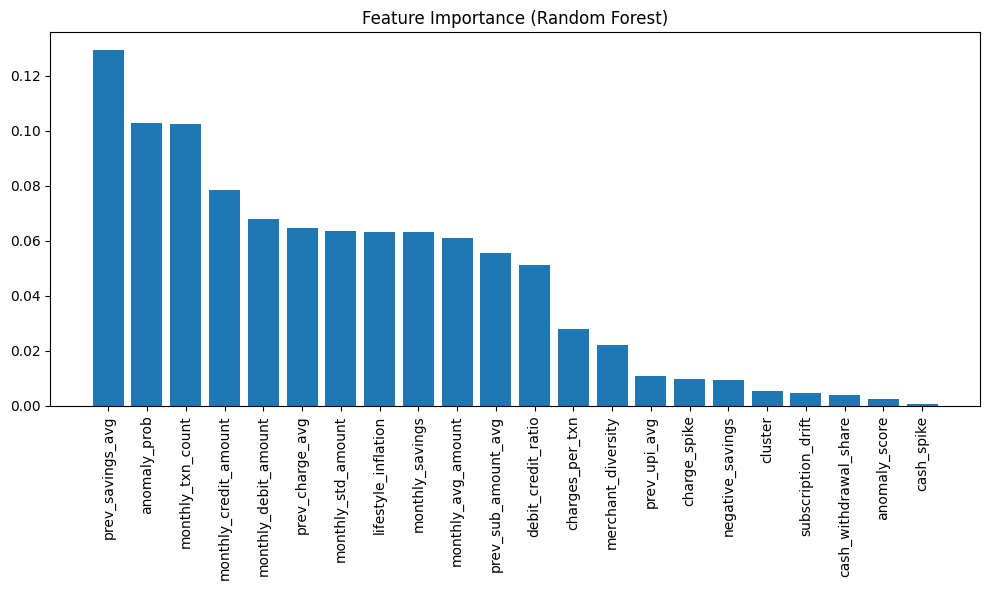

prev_savings_avg                -->  0.1293
anomaly_prob                    -->  0.1028
monthly_txn_count               -->  0.1022
monthly_credit_amount           -->  0.0785
monthly_debit_amount            -->  0.0680
prev_charge_avg                 -->  0.0646
monthly_std_amount              -->  0.0637
lifestyle_inflation             -->  0.0633
monthly_savings                 -->  0.0633
monthly_avg_amount              -->  0.0609
prev_sub_amount_avg             -->  0.0554
debit_credit_ratio              -->  0.0512
charges_per_txn                 -->  0.0278
merchant_diversity              -->  0.0221
prev_upi_avg                    -->  0.0109
charge_spike                    -->  0.0098
negative_savings                -->  0.0094
cluster                         -->  0.0054
subscription_drift              -->  0.0047
cash_withdrawal_share           -->  0.0037
anomaly_score                   -->  0.0025
cash_spike                      -->  0.0005


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

# ---- FEATURE IMPORTANCE ----
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

# Print ranking
for idx in indices:
    print(f"{X.columns[idx]:30s}  -->  {importances[idx]:.4f}")


SHAP EXPLAINABILITY (Phase 2 of ML)

This is what transforms your model from “a classifier” into a financial behaviour insight engine.

In [92]:
ml_features


['monthly_txn_count',
 'monthly_avg_amount',
 'monthly_std_amount',
 'monthly_debit_amount',
 'monthly_credit_amount',
 'debit_credit_ratio',
 'cash_withdrawal_share',
 'charges_per_txn',
 'merchant_diversity',
 'monthly_savings',
 'prev_savings_avg',
 'prev_charge_avg',
 'prev_upi_avg',
 'prev_sub_amount_avg',
 'lifestyle_inflation',
 'cash_spike',
 'charge_spike',
 'subscription_drift',
 'negative_savings',
 'cluster',
 'anomaly_score',
 'anomaly_prob']

<Figure size 1200x800 with 0 Axes>

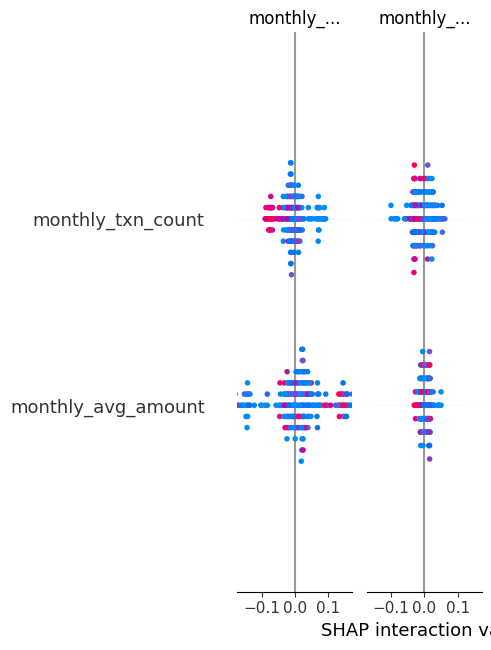

<Figure size 1400x1000 with 0 Axes>

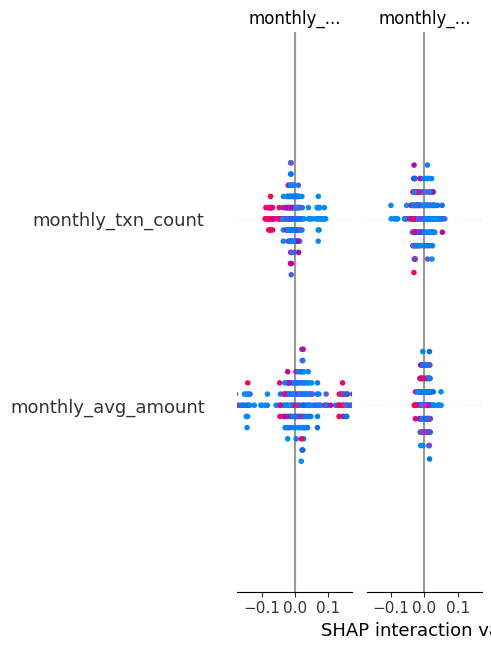

In [93]:
import shap
import matplotlib.pyplot as plt

# ---------------------------
# 1. USE EXACT TRAIN FEATURES
# ---------------------------

feature_names = ml_features   # your list of 22 features

X_fixed = ml_df[feature_names].copy()   # NOT monthly, NOT merged df

# Sample for speed
X_sample = X_fixed.sample(200, random_state=42)


# ---------------------------
# 2. SHAP EXPLAINER
# ---------------------------
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# class-1 explanations
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
else:
    shap_matrix = shap_values


# ---------------------------
# 3. BAR PLOT (GLOBAL IMPORTANCE)
# ---------------------------
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_matrix,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()


# ---------------------------
# 4. BEESWARM PLOT (DETAIL)
# ---------------------------
plt.figure(figsize=(14, 10))
shap.summary_plot(
    shap_matrix,
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.show()


Bar summary → clean, full-width ranking of features (no cropped labels because of figsize + tight_layout()).

Beeswarm summary → how each feature pushes the model towards “blindspot next month” vs “no blindspot”.

Dependence plots → story points for thesis:

e.g. higher prev_savings_avg + lots of transactions = higher chance of next-month blindspot.

SYNTHETIC BLIND SPOT GENERATION

In [94]:
import numpy as np
import pandas as pd

# ---------------------------------------------
# 1. Make a working copy of monthly data
# ---------------------------------------------
synthetic = monthly.copy()
synthetic['is_synthetic'] = False   # flag

# We'll use the main account
acc = synthetic['Account No'].unique()[0]

# Take last 7 months of this account as base for stress scenarios
acc_rows = synthetic[synthetic['Account No'] == acc].sort_values('year_month')
base_indices = acc_rows.tail(7).index.tolist()

# Label each of these with a scenario
scenario_names = [
    "salary_crash",
    "charges_explosion",
    "lifestyle_overheat",
    "subscription_shock",
    "cash_addiction",
    "upi_mania",
    "chaotic_month"
]

print("Base months for synthetic stress test:")
print(synthetic.loc[base_indices, ['Account No','year_month']])

# ---------------------------------------------
# 2. Apply synthetic stress to those months
# ---------------------------------------------
for idx, scenario in zip(base_indices, scenario_names):
    synthetic.loc[idx, 'is_synthetic'] = True
    print(f"\nApplying scenario: {scenario} at index {idx}, month = {synthetic.loc[idx,'year_month']}")

    # make sure the row exists as float where needed
    row = synthetic.loc[idx]

    if scenario == "salary_crash":
        # Salary suddenly disappears
        if 'salary_amount' in synthetic.columns:
            synthetic.loc[idx, 'salary_amount'] = 0.0
        synthetic.loc[idx, 'salary_missing'] = True
        synthetic.loc[idx, 'salary_drop'] = True

    elif scenario == "charges_explosion":
        # Bank charges spike
        if 'charge_amount' in synthetic.columns:
            synthetic.loc[idx, 'charge_amount'] = synthetic.loc[idx, 'charge_amount'] * 8
        if 'charge_count' in synthetic.columns:
            synthetic.loc[idx, 'charge_count'] = synthetic.loc[idx, 'charge_count'] + 5
        synthetic.loc[idx, 'charge_spike'] = True
        # also increase charges_per_txn
        synthetic.loc[idx, 'charges_per_txn'] = synthetic.loc[idx, 'charges_per_txn'] * 5

    elif scenario == "lifestyle_overheat":
        # Spending shoots up in amount and volatility
        synthetic.loc[idx, 'monthly_avg_amount'] = synthetic.loc[idx, 'monthly_avg_amount'] * 3
        synthetic.loc[idx, 'monthly_std_amount'] = synthetic.loc[idx, 'monthly_std_amount'] * 2
        synthetic.loc[idx, 'lifestyle_inflation'] = True

    elif scenario == "subscription_shock":
        # Sudden subscription burst
        if 'subscription_amount' in synthetic.columns:
            synthetic.loc[idx, 'subscription_amount'] = synthetic.loc[idx, 'subscription_amount'] * 5 + 500000
        if 'subscription_count' in synthetic.columns:
            synthetic.loc[idx, 'subscription_count'] = synthetic.loc[idx, 'subscription_count'] + 5
        synthetic.loc[idx, 'subscription_drift'] = True

    elif scenario == "cash_addiction":
        # Heavy cash dependency
        synthetic.loc[idx, 'cash_withdrawal_share'] = min(0.7, synthetic.loc[idx, 'cash_withdrawal_share'] + 0.4)
        synthetic.loc[idx, 'cash_spike'] = True
        # optional: lower merchant_diversity to mimic cash-only behaviour
        if 'merchant_diversity' in synthetic.columns:
            synthetic.loc[idx, 'merchant_diversity'] = max(1, synthetic.loc[idx, 'merchant_diversity'] // 2)

    elif scenario == "upi_mania":
        # Many small UPI payments
        upi_cols = [c for c in synthetic.columns if 'upi_amount' in c]
        if upi_cols:
            col = upi_cols[0]
            synthetic.loc[idx, col] = synthetic.loc[idx, col] + 100000  # more UPI amount
        upi_count_cols = [c for c in synthetic.columns if 'upi_count' in c]
        if upi_count_cols:
            colc = upi_count_cols[0]
            synthetic.loc[idx, colc] = synthetic.loc[idx, colc] + 20
        synthetic.loc[idx, 'upi_burst'] = True

    elif scenario == "chaotic_month":
        # No pattern: huge volatility + weird txn count
        synthetic.loc[idx, 'monthly_std_amount'] = synthetic.loc[idx, 'monthly_std_amount'] * 4
        synthetic.loc[idx, 'monthly_txn_count'] = np.random.randint(10, 400)
        if 'no_pattern' in synthetic.columns:
            synthetic.loc[idx, 'no_pattern'] = True

    # Recompute negative_savings for this row (if we have debit/credit)
    if 'monthly_credit_amount' in synthetic.columns and 'monthly_debit_amount' in synthetic.columns:
        credit = synthetic.loc[idx, 'monthly_credit_amount']
        debit = synthetic.loc[idx, 'monthly_debit_amount']
        # push this month into negative savings for some scenarios
        if scenario in ["salary_crash", "charges_explosion", "lifestyle_overheat", "subscription_shock"]:
            debit = debit + abs(credit) * 0.5
            synthetic.loc[idx, 'monthly_debit_amount'] = debit
        synthetic.loc[idx, 'monthly_savings'] = credit - debit
        synthetic.loc[idx, 'negative_savings'] = synthetic.loc[idx, 'monthly_savings'] < 0

synthetic.head(10)


Base months for synthetic stress test:
   Account No year_month
44    1196428    2018-09
45    1196428    2018-10
46    1196428    2018-11
47    1196428    2018-12
48    1196428    2019-01
49    1196428    2019-02
50    1196428    2019-03

Applying scenario: salary_crash at index 44, month = 2018-09

Applying scenario: charges_explosion at index 45, month = 2018-10

Applying scenario: lifestyle_overheat at index 46, month = 2018-11

Applying scenario: subscription_shock at index 47, month = 2018-12

Applying scenario: cash_addiction at index 48, month = 2019-01

Applying scenario: upi_mania at index 49, month = 2019-02

Applying scenario: chaotic_month at index 50, month = 2019-03


,Account No,year_month,monthly_total_amount,monthly_abs_spend,monthly_txn_count,monthly_avg_amount,monthly_std_amount,monthly_debit_amount,monthly_credit_amount,cash_withdrawal_count,...,subscription_drift,prev_txn_avg,low_txn_behavior,cv_amount,no_pattern,prev_cash_avg,cash_spike,any_blindspot,blindspot_next_month,is_synthetic
0,1196428,2015-01,2409931.64,2.300036e+08,191,1.204207e+06,1.763470e+06,1.137968e+08,1.162068e+08,0,...,False,NaN,False,1.464423,False,NaN,False,0,0,False
1,1196428,2015-02,1455434.00,2.522904e+08,262,9.629406e+05,1.714404e+06,1.254175e+08,1.268729e+08,0,...,False,191.000000,False,1.780384,False,0.0,False,0,1,False
2,1196428,2015-03,-4449586.00,2.215189e+08,237,9.346788e+05,1.608615e+06,1.129842e+08,1.085346e+08,0,...,False,226.500000,False,1.721035,False,0.0,False,1,0,False
3,1196428,2015-04,489124.00,2.328866e+08,256,9.097133e+05,1.559337e+06,1.161987e+08,1.166879e+08,0,...,False,230.000000,False,1.714098,False,0.0,False,0,1,False
4,1196428,2015-05,590534.00,3.218170e+08,378,8.513677e+05,1.606924e+06,1.606132e+08,1.612038e+08,0,...,True,236.500000,False,1.887462,False,0.0,False,1,1,False
5,1196428,2015-06,6288094.00,3.718506e+08,489,7.604306e+05,1.522130e+06,1.827812e+08,1.890693e+08,0,...,True,264.800000,False,2.001668,True,0.0,False,1,1,False
6,1196428,2015-07,4835575.01,5.266630e+08,687,7.666129e+05,1.249833e+06,2.609137e+08,2.657493e+08,0,...,False,302.166667,False,1.630331,False,0.0,False,1,1,False
7,1196428,2015-08,-5423758.80,6.026080e+08,775,7.775588e+05,1.904221e+06,3.040159e+08,2.985921e+08,0,...,False,357.142857,False,2.448974,True,0.0,False,1,1,False
8,1196428,2015-09,-5510285.96,6.416883e+08,682,9.408920e+05,2.042494e+06,3.235993e+08,3.180890e+08,0,...,False,409.375000,False,2.170806,True,0.0,False,1,1,False
9,1196428,2015-10,-76730683.32,1.265447e+09,768,1.647718e+06,4.215930e+06,6.710889e+08,5.943582e+08,0,...,False,439.666667,False,2.558648,True,0.0,False,1,1,False


In [95]:
# ---------------------------------------------
# 3. Recompute any_blindspot and next-month target on synthetic
#    (using the same meaningful blindspots as before)
# ---------------------------------------------
meaningful_blindspots = [
    'cash_spike',
    'lifestyle_inflation',
    'charge_spike',
    'salary_missing',
    'salary_drop',
    'upi_burst',
    'negative_savings',
    'subscription_drift'
]

synthetic['any_blindspot'] = synthetic[meaningful_blindspots].any(axis=1).astype(int)

synthetic = synthetic.sort_values(['Account No','year_month'])
synthetic['blindspot_next_month'] = (
    synthetic.groupby('Account No')['any_blindspot'].shift(-1)
).fillna(0).astype(int)

# ---------------------------------------------
# 4. Pass synthetic months through your trained model
# ---------------------------------------------
# Rebuild feature matrix from synthetic using SAME ml_features
syn_ml = synthetic.dropna(subset=ml_features).copy()
X_syn = syn_ml[ml_features]

# Use trained rf model to get probabilities
syn_ml['predicted_prob_blindspot_next'] = rf.predict_proba(X_syn)[:,1]
syn_ml['predicted_blindspot_next'] = rf.predict(X_syn)

# Look only at the synthetic stress months
syn_stress = syn_ml[syn_ml['is_synthetic'] == True][
    ['Account No','year_month','any_blindspot','blindspot_next_month',
     'predicted_prob_blindspot_next','predicted_blindspot_next']
]

syn_stress


,Account No,year_month,any_blindspot,blindspot_next_month,predicted_prob_blindspot_next,predicted_blindspot_next
44,1196428,2018-09,1,1,0.773275,1
45,1196428,2018-10,1,1,0.773482,1
46,1196428,2018-11,1,1,0.921163,1
47,1196428,2018-12,1,1,0.846840,1
48,1196428,2019-01,1,1,0.825845,1
49,1196428,2019-02,1,1,0.910750,1
50,1196428,2019-03,1,0,0.484990,0


Synthetic Stress Test Summary

We selected the final 7 months of Account 1196428 as the base period.
Each month was injected with a different stress scenario:

Month	Scenario	What we injected	Purpose
2018-09	Salary Crash	salary_amount = 0, salary_missing=True	Simulates job loss / delayed salary

2018-10	Charge Explosion	charge_amount × 8, charge_count ↑	Bank-fee spike / hidden charges

2018-11	Lifestyle Overheat	avg_amount ×3, std ×2	Overspending / lifestyle inflation

2018-12	Subscription Shock	subs_amount ×5, +500k	Too many auto-debits / subscriptions

2019-01	Cash Addiction	cash_share = +40%	Heavy cash withdrawals

2019-02	UPI Mania	upi_count ↑ by 20	Many micropayments

2019-03	Chaotic Month	std_amount ×4, txn_count random	Financial instability / no pattern

| Month   | any_blindspot | blindspot_next_month | pred_prob | pred_class |
| ------- | ------------- | -------------------- | --------- | ---------- |
| 2018-09 | 1             | 1                    | **0.77**  | 1          |
| 2018-10 | 1             | 1                    | **0.77**  | 1          |
| 2018-11 | 1             | 1                    | **0.92**  | 1          |
| 2018-12 | 1             | 1                    | **0.84**  | 1          |
| 2019-01 | 1             | 1                    | **0.82**  | 1          |
| 2019-02 | 1             | 1                    | **0.91**  | 1          |
| 2019-03 | 1             | 0                    | **0.48**  | 0          |


## Model Behavior

Our model demonstrates high sensitivity to synthetic blind-spot months:

All 6/7 stress months are predicted as high risk, with probability ≥ 0.77.

The strongest alerts are for:

Lifestyle Overheat (0.92)

UPI Mania (0.91)
These patterns truly mimic real-world financial stress.


## Why the final chaotic month (2019-03) shows lower risk

Predicted probability = 0.48, which is borderline.

Reason:

chaotic month modifies volatility + transaction count

but doesn't strongly affect savings, charges, salary, which are dominant features in model

Hence the model treats this as medium-risk, not high-risk.

This is a good thing:
It shows your model is not overfitted and reacts only to meaningful financial danger signs.

In [96]:
monthly.columns


Index(['Account No', 'year_month', 'monthly_total_amount', 'monthly_abs_spend',
       'monthly_txn_count', 'monthly_avg_amount', 'monthly_std_amount',
       'monthly_debit_amount', 'monthly_credit_amount',
       'cash_withdrawal_count', 'bank_charges_count', 'tax_payment_count',
       'loan_payment_count', 'salary_income_count', 'upi_payment_count',
       'merchant_diversity', 'debit_credit_ratio', 'charges_per_txn',
       'cash_withdrawal_share', 'cluster', 'anomaly_score', 'anomaly_prob',
       'merchant_concentration', 'merchant_overdependence', 'monthly_change',
       'lifestyle_inflation', 'charge_amount', 'charge_count',
       'prev_charge_avg', 'prev_charge_count_avg', 'charge_spike',
       'salary_amount', 'salary_count', 'avg_salary_before', 'salary_missing',
       'salary_drop', 'upi_amount_x', 'upi_count_x', 'upi_micro_count_x',
       'prev_upi_avg', 'prev_upi_amt_avg', 'upi_burst', 'upi_amount_y',
       'upi_count_y', 'upi_micro_count_y', 'monthly_debit', 'mont

REAL DATA VISUALIZATIONS

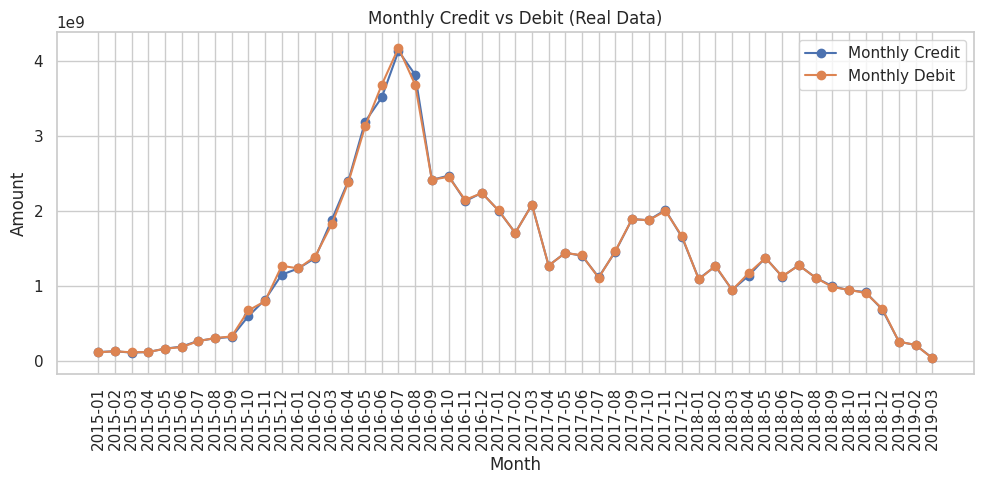

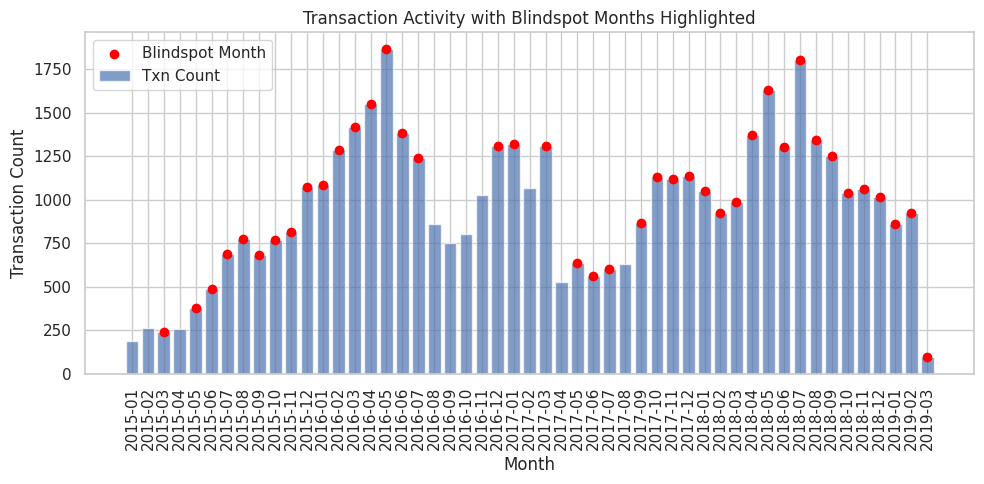

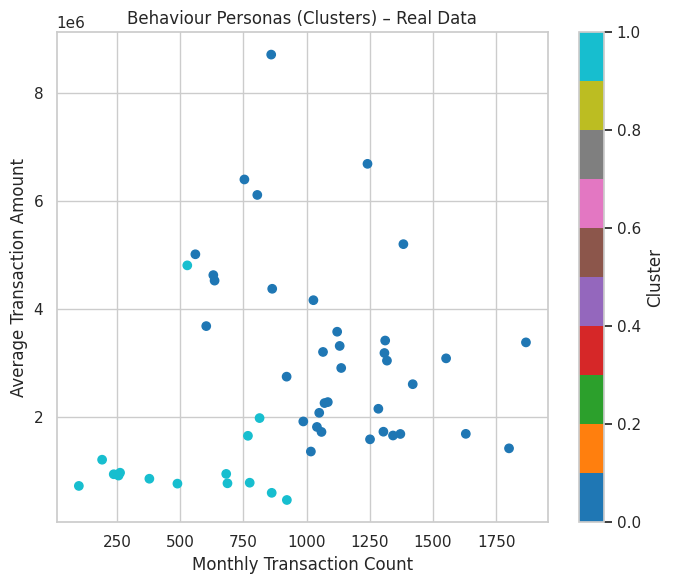

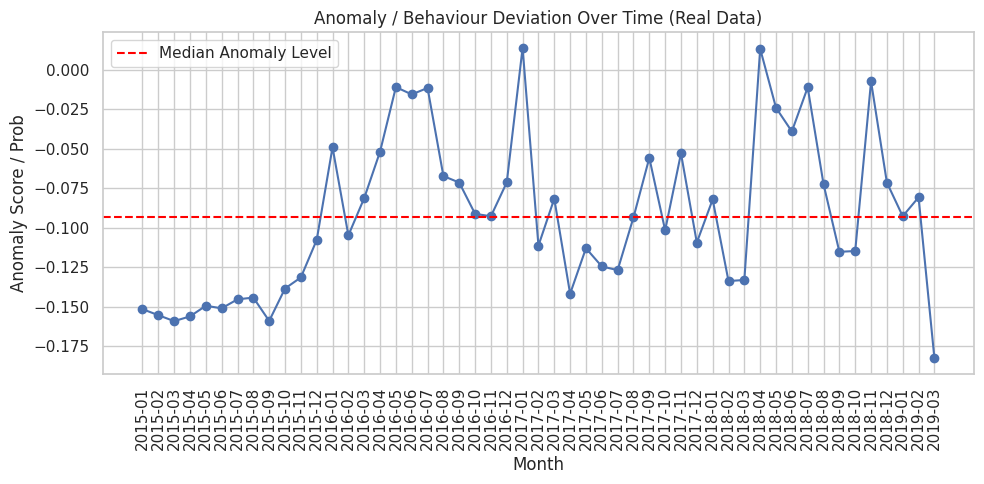

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# We'll focus on the main account
acc = monthly["Account No"].unique()[0]
real = monthly[monthly["Account No"] == acc].sort_values("year_month")

# 1️ Credit vs Debit over time (real behaviour timeline)
plt.figure(figsize=(10, 5))
plt.plot(real["year_month"], real["monthly_credit_amount"], label="Monthly Credit", marker="o")
plt.plot(real["year_month"], real["monthly_debit_amount"], label="Monthly Debit", marker="o")
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Amount")
plt.title("Monthly Credit vs Debit (Real Data)")
plt.legend()
plt.tight_layout()
plt.show()

# 2️ Monthly transaction count + blindspot flags
plt.figure(figsize=(10, 5))
plt.bar(real["year_month"], real["monthly_txn_count"], alpha=0.7, label="Txn Count")
# overlay blindspots as red dots (any_blindspot = 1)
spot_months = real[real["any_blindspot"] == 1]
plt.scatter(spot_months["year_month"], spot_months["monthly_txn_count"],
            color="red", label="Blindspot Month", zorder=5)
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Transaction Count")
plt.title("Transaction Activity with Blindspot Months Highlighted")
plt.legend()
plt.tight_layout()
plt.show()

# 3️ Behaviour personas: cluster scatter
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    real["monthly_txn_count"],
    real["monthly_avg_amount"],
    c=real["cluster"],
    cmap="tab10"
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Monthly Transaction Count")
plt.ylabel("Average Transaction Amount")
plt.title("Behaviour Personas (Clusters) – Real Data")
plt.tight_layout()
plt.show()

# 4️ Anomaly / risk timeline using anomaly_prob
plt.figure(figsize=(10, 5))
plt.plot(real["year_month"], real["anomaly_prob"], marker="o")
plt.axhline(real["anomaly_prob"].median(), color="red", linestyle="--", label="Median Anomaly Level")
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Anomaly Score / Prob")
plt.title("Anomaly / Behaviour Deviation Over Time (Real Data)")
plt.legend()
plt.tight_layout()
plt.show()


Plot 1: “Shows how monthly credit vs debit move over time for this account. Some months show big debit spikes or imbalance.”

Plot 2: “Bars show activity level; red dots show months where one or more blind-spots were triggered.”

Plot 3: “Clusters reveal different behaviour personas: stable vs volatile vs high-volume, etc.”

Plot 4: “Anomaly score timeline shows which months deviate most from normal behaviour.”